In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# from datasets import load_dataset  ## datasets load krvane me help kregi


## Fixing random seeds

I noticed my results were changing a lot every time I reran this notebook - like my OOD accuracy went from 30% to 66% between two runs of literally the same code. Took me a while to realize I never set a random seed anywhere, so every model was starting from different random weights each time.

Adding this at the top so every "Restart & Run All" starts from the same point. Doing this before building any model.

In [2]:
import os
import random
import numpy as np
import tensorflow as tf

SEED = 2024 # <-- change this to 42, then 123, then 2024 for the 3 trial runs
os.environ["PYTHONHASHSEED"] = str(SEED)
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"Seeds fixed to {SEED} for reproducibility.")


Seeds fixed to 2024 for reproducibility.


## 2. Load Dataset
Load the dair-ai/emotion dataset from Hugging Face. https://huggingface.co/datasets/dair-ai/emotion

In [3]:
# Loading from local CSV files instead of HuggingFace directly (no internet needed, and lets us use the augmented training set with more love/surprise examples)
_df_train_raw = pd.read_csv('train_augmented_v2.csv')   # augmented: more love + surprise examples
_df_test_raw  = pd.read_csv('test.csv')                  # ORIGINAL, unaugmented -- never touch eval data
_df_val_raw   = pd.read_csv('val.csv')                   # ORIGINAL, unaugmented

print("train:", _df_train_raw.shape, "| test:", _df_test_raw.shape, "| val:", _df_val_raw.shape)
_df_train_raw['label'].value_counts().sort_index()


train: (19996, 2) | test: (2000, 2) | val: (2000, 2)


label
0    4665
1    5353
2    3215
3    2153
4    1932
5    2678
Name: count, dtype: int64

In [4]:
train_text      = _df_train_raw['text'].tolist()
train_label     = _df_train_raw['label'].tolist()

test_text       = _df_test_raw['text'].tolist()
test_label      = _df_test_raw['label'].tolist()

val_text        = _df_val_raw['text'].tolist()
val_label       = _df_val_raw['label'].tolist()


In [5]:
label_names = ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
label_names


['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']

In [6]:
# quick sanity check, commented out because it prints ~20k lines
# for i in train_label:
#     print(label_names[i])


In [7]:
df_train = pd.DataFrame({'text': train_text, 'label': [label_names[i] for i in train_label]})
df_test = pd.DataFrame({'text': test_text, 'label': [label_names[i] for i in test_label]})
df_val= pd.DataFrame({'text': val_text, 'label': [label_names[i] for i in val_label]})

In [8]:
df_train.head()


,text,label
0,i usually use smaller legos however this year ...,joy
1,i can feel your heartbeat with each desire lon...,love
2,these days i cant imagine my life without my l...,love
3,i assert it is better to feel rich than to be ...,joy
4,i feel annoyed at the fact that i m three week...,anger


In [9]:
df_train.isnull().sum()

text     0
label    0
dtype: int64

## EDA

<Axes: xlabel='label', ylabel='count'>

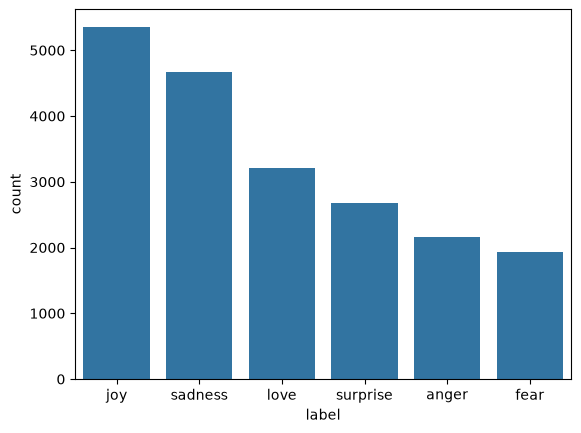

In [10]:
sns.countplot(x='label', data=df_train,order=df_train['label'].value_counts().index )

In [11]:
df_train

,text,label
0,i usually use smaller legos however this year ...,joy
1,i can feel your heartbeat with each desire lon...,love
2,these days i cant imagine my life without my l...,love
3,i assert it is better to feel rich than to be ...,joy
4,i feel annoyed at the fact that i m three week...,anger
...,...,...
19991,i feel soo dull these days,sadness
19992,lately my heart aches with love whenever i see...,love
19993,i love winter so maybe i should be happy but i...,sadness
19994,i see that i have pageviews and im just guessi...,joy


## Data Preprocessing - Using NLP

In [12]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
max_words = 10000

tokenizer = Tokenizer(num_words=max_words, oov_token='')
tokenizer.fit_on_texts(df_train['text'])

train_sequence = tokenizer.texts_to_sequences(df_train['text'])
test_sequenece = tokenizer.texts_to_sequences(df_test['text'])

padded_train_sequence = pad_sequences(train_sequence,maxlen=50,padding='post', truncating='post')
padded_test_sequence = pad_sequences(test_sequenece ,maxlen=50,padding='post', truncating='post')
padded_val_sequence = pad_sequences(tokenizer.texts_to_sequences(df_val['text']),maxlen=50,padding='post', truncating='post')

train_labels = np.array(train_label)
test_labels  = np.array(test_label)
val_labels   = np.array(val_label)

num_classes = len(np.unique(train_labels))
num_classes


print(f"Vocabulary Size: {len(tokenizer.word_index)}")
print(f"Max Sentence Length: {padded_train_sequence.shape[1]}")

Vocabulary Size: 15256
Max Sentence Length: 50


 ## 5. shared Traing Utilities
compute balanced class weights to handle dataset skew and setup early stoping 

In [13]:
from sklearn.utils import class_weight

class_weights = class_weight.compute_class_weight(
    class_weight = 'balanced',
    classes      = np.unique(train_labels),
    y            = train_labels
)

class_weight_dict = dict(enumerate(class_weights))

In [14]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
early_stopping = EarlyStopping(
    monitor   ='val_loss',
    patience  =3, 
    restore_best_weights=True
    )



## 6. Plain Foundational Models
train plain(non-bidirectional) Simple RNN, Standard LSTM and Standard GRU models

In [15]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Embedding, Dense, Dropout, LSTM, GRU

rnn_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    SimpleRNN(units=128, return_sequences=True),
    Dropout(0.5),
    SimpleRNN(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

rnn_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

d:\emotion-classification-nlp\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [16]:
rnn_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_val_sequence, val_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

rnn_loss, rnn_accuracy = rnn_model.evaluate(padded_test_sequence, test_labels)
print(f"RNN Loss: {rnn_loss}")
print(f"RNN Accuracy: {rnn_accuracy}")
     

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 42s 62ms/step - accuracy: 0.2887 - loss: 1.7185 - val_accuracy: 0.3255 - val_loss: 1.7570
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 21s 33ms/step - accuracy: 0.3380 - loss: 1.4637 - val_accuracy: 0.3205 - val_loss: 1.6927
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.3203 - loss: 1.4866 - val_accuracy: 0.1980 - val_loss: 1.6969
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 18s 29ms/step - accuracy: 0.3317 - loss: 1.4547 - val_accuracy: 0.1805 - val_loss: 1.6848
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.3471 - loss: 1.4129 - val_accuracy: 0.1635 - val_loss: 1.6921
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.3103 - loss: 1.5239 - val_accuracy: 0.3150 - val_loss: 1.6901
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 16s 25ms/step - accuracy: 0.2927 - loss: 1.6232 - val_accuracy: 0.3195 - val_loss: 1.7114
63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.1715 - loss: 1.6630
RNN Loss: 1.66302

## Standard LSTM

In [17]:
lstm_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    LSTM(units=128, return_sequences=True),
    Dropout(0.5),
    LSTM(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

lstm_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

lstm_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_val_sequence, val_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

lstm_loss, lstm_accuracy = lstm_model.evaluate(padded_test_sequence, test_labels)
print(f"LSTM Loss: {lstm_loss}")
print(f"LSTM Accuracy: {lstm_accuracy}")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 49ms/step - accuracy: 0.2262 - loss: 1.6971 - val_accuracy: 0.2730 - val_loss: 1.7818
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.1940 - loss: 1.7686 - val_accuracy: 0.3490 - val_loss: 1.7847
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 77s 123ms/step - accuracy: 0.1923 - loss: 1.7581 - val_accuracy: 0.3515 - val_loss: 1.7814
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 41s 66ms/step - accuracy: 0.1993 - loss: 1.7476 - val_accuracy: 0.3515 - val_loss: 1.7801
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 31s 50ms/step - accuracy: 0.1930 - loss: 1.7403 - val_accuracy: 0.3515 - val_loss: 1.7763
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 29s 46ms/step - accuracy: 0.1905 - loss: 1.7376 - val_accuracy: 0.3515 - val_loss: 1.7766
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 28s 45ms/step - accuracy: 0.2030 - loss: 1.7346 - val_accuracy: 0.3515 - val_loss: 1.7774
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 26s 42ms/step - accuracy: 0.2051 - loss: 1.7343 

## Standard GRU

In [18]:
gru_model = Sequential([
    Embedding(input_dim = max_words, output_dim = 128 , input_length = 50),
    GRU(units=128, return_sequences=True),
    Dropout(0.5),
    GRU(units=64),
    Dropout(0.5),
    Dense(units=num_classes, activation='softmax') #Output Layer
])

gru_model.compile(optimizer='adam',loss='sparse_categorical_crossentropy',metrics=['accuracy'])

gru_model.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_test_sequence, test_labels),
    epochs = 20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

gru_loss, gru_accuracy = gru_model.evaluate(padded_test_sequence, test_labels)
print(f"GRU Loss: {gru_loss}")
print(f"GRU Accuracy: {gru_accuracy}")

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 61ms/step - accuracy: 0.1597 - loss: 1.7952 - val_accuracy: 0.0815 - val_loss: 1.7827
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.1596 - loss: 1.7943 - val_accuracy: 0.3455 - val_loss: 1.7768
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 33s 53ms/step - accuracy: 0.1640 - loss: 1.7937 - val_accuracy: 0.1405 - val_loss: 1.7701
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 37s 60ms/step - accuracy: 0.1640 - loss: 1.7928 - val_accuracy: 0.1450 - val_loss: 1.7678
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.1679 - loss: 1.7874 - val_accuracy: 0.2075 - val_loss: 1.7783
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 61s 98ms/step - accuracy: 0.3058 - loss: 1.5234 - val_accuracy: 0.3370 - val_loss: 1.5323
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 51s 81ms/step - accuracy: 0.6515 - loss: 0.7941 - val_accuracy: 0.7645 - val_loss: 0.7457
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 54s 87ms/step - accuracy: 0.8287 - loss: 0.4353 -

In [19]:
results_df=pd.DataFrame({
    'Model': ['RNN', 'LSTM', 'GRU'],
    'Test Loss': [rnn_loss, lstm_loss, gru_loss],
    'Test Accuracy': [rnn_accuracy, lstm_accuracy, gru_accuracy]
}).sort_values(by='Test Accuracy', ascending=False).reset_index(drop=True)
results_df

,Model,Test Loss,Test Accuracy
0,LSTM,0.215476,0.9175
1,GRU,0.233723,0.9170
2,RNN,1.663024,0.1715


## Advanced Bidirectional GRU
Enhance GRU with Bidirectional layers embeddings and 0.5 dropout regularization

In [20]:
from tensorflow.keras.layers import Bidirectional

BiGRU = Sequential([
    Embedding(input_dim = max_words, output_dim = 300 , input_length = 50),
    Bidirectional(GRU(128, return_sequences=True)),
    Dropout(0.5),
    Bidirectional(GRU(64)),
    Dropout(0.5),
    Dense(num_classes, activation='softmax') #Output Layer
    #Why i used num_classes in output layer and what will i get from this.
])

BiGRU.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

BiGRU.summary()

d:\emotion-classification-nlp\venv\Lib\site-packages\keras\src\layers\core\embedding.py:123: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding_3 (Embedding)         │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional (Bidirectional)   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ ?                      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [21]:
BiGRU.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_val_sequence, val_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)

Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 228s 343ms/step - accuracy: 0.6744 - loss: 0.8103 - val_accuracy: 0.9065 - val_loss: 0.2612
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 140s 225ms/step - accuracy: 0.9415 - loss: 0.1721 - val_accuracy: 0.9200 - val_loss: 0.2202
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 85s 135ms/step - accuracy: 0.9632 - loss: 0.1037 - val_accuracy: 0.9180 - val_loss: 0.2331
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 83s 133ms/step - accuracy: 0.9721 - loss: 0.0826 - val_accuracy: 0.9260 - val_loss: 0.2341
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 97s 155ms/step - accuracy: 0.9798 - loss: 0.0584 - val_accuracy: 0.9285 - val_loss: 0.2800


In [22]:
from sklearn.metrics import f1_score, classification_report
import numpy as np

# Evaluate model
BiGRU_loss, BiGRU_accuracy = BiGRU.evaluate(
    padded_test_sequence,
    test_labels
)

print(f"BiGRU Loss: {BiGRU_loss:.4f}")
print(f"BiGRU Accuracy: {BiGRU_accuracy:.4f}")

# Predictions
y_prob = BiGRU.predict(padded_test_sequence)
y_pred = np.argmax(y_prob, axis=1)

# F1 scores
macro_f1 = f1_score(test_labels, y_pred, average='macro')
weighted_f1 = f1_score(test_labels, y_pred, average='weighted')

print(f"BiGRU Macro F1 Score: {macro_f1:.4f}")
print(f"BiGRU Weighted F1 Score: {weighted_f1:.4f}")

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step - accuracy: 0.9150 - loss: 0.2143
BiGRU Loss: 0.2143
BiGRU Accuracy: 0.9150
63/63 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step
BiGRU Macro F1 Score: 0.8697
BiGRU Weighted F1 Score: 0.9162


## Overall Evaluation & Bias Analysis

63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step


<Axes: >

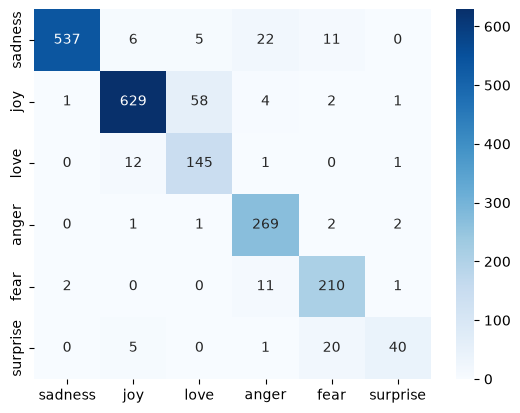

In [23]:
from sklearn.metrics import  confusion_matrix
BiGRU_predictions = np.argmax(
    BiGRU.predict(padded_test_sequence),
    axis=1
)

sns.heatmap(
    confusion_matrix(test_labels, BiGRU_predictions),
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=label_names,
    yticklabels=label_names
)

## Final Predictions


In [24]:
sample_text = [
    "I got the job I always wanted!",
    "Today has been a wonderful day.",
    "I can't stop smiling after hearing the good news.",
    "I lost someone very close to me.",
    "Nothing seems to be going right today.",
    "I feel lonely and hopeless.",
    "This is absolutely unacceptable!",
    "I am really frustrated with what happened.",
    "How could they treat me like this?",
    "I heard a strange noise outside my room.",
    "I am nervous about what might happen.",
    "Walking alone in this place makes me uncomfortable.",
    "I am extremely grateful for everything you have done.",
    "I hate what happened today.",
    "I am excited about my vacation tomorrow.",
    "I suddenly heard a loud noise behind me.",
    "I am worried that I might lose my job.",
    "My best friend gave me a beautiful surprise.",
    "I don't want to talk to anyone today.",
    "I am furious about the unfair decision."
]
sequences = tokenizer.texts_to_sequences(sample_text)

padded_sequences = pad_sequences(
    sequences,
    maxlen=50,
    padding='post',
    truncating='post'
)

predictions = lstm_model.predict(padded_sequences)

predicted_classes = np.argmax(predictions, axis=1)

for text, pred in zip(sample_text, predicted_classes):
    print(f"Text: {text}")
    print(f"Predicted Emotion: {label_names[pred]}")
    print("-" * 60)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 264ms/step
Text: I got the job I always wanted!
Predicted Emotion: joy
------------------------------------------------------------
Text: Today has been a wonderful day.
Predicted Emotion: joy
------------------------------------------------------------
Text: I can't stop smiling after hearing the good news.
Predicted Emotion: joy
------------------------------------------------------------
Text: I lost someone very close to me.
Predicted Emotion: anger
------------------------------------------------------------
Text: Nothing seems to be going right today.
Predicted Emotion: joy
------------------------------------------------------------
Text: I feel lonely and hopeless.
Predicted Emotion: sadness
------------------------------------------------------------
Text: This is absolutely unacceptable!
Predicted Emotion: fear
------------------------------------------------------------
Text: I am really frustrated with what happened.
Predicted Emotion: anger
----

In [25]:
sample_text = [
    "Today has been a wonderful day.",
    "I can't stop smiling after hearing the good news.",

    "I lost someone very close to me.",
    "Nothing seems to be going right today.",
    "I feel lonely and hopeless.",

    "I am really frustrated with what happened.",
    "How could they treat me like this?",

    "I heard a strange noise outside my room.",
    "I am nervous about what might happen.",
    "Walking alone in this place makes me uncomfortable.",

    "I never expected this to happen!",
    "Wow, I didn't see that coming.",
    "The news completely shocked me.",

    "I really appreciate everything you have done for me.",
    "I care deeply about my family.",
    "You are one of the most important people in my life."
]

sample_sequences = tokenizer.texts_to_sequences(sample_text)

sample_padded_sequences = pad_sequences(
    sample_sequences,
    maxlen=50,
    padding='post',
    truncating='post'
)

sample_predictions = np.argmax(
    BiGRU.predict(sample_padded_sequences),
    axis=1
)

for i in range(len(sample_text)):
    print(
        f"Text: {sample_text[i]}\n"
        f"Predicted Emotion: {label_names[sample_predictions[i]]}"
    ) 

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Text: Today has been a wonderful day.
Predicted Emotion: joy
Text: I can't stop smiling after hearing the good news.
Predicted Emotion: joy
Text: I lost someone very close to me.
Predicted Emotion: sadness
Text: Nothing seems to be going right today.
Predicted Emotion: fear
Text: I feel lonely and hopeless.
Predicted Emotion: sadness
Text: I am really frustrated with what happened.
Predicted Emotion: anger
Text: How could they treat me like this?
Predicted Emotion: surprise
Text: I heard a strange noise outside my room.
Predicted Emotion: fear
Text: I am nervous about what might happen.
Predicted Emotion: fear
Text: Walking alone in this place makes me uncomfortable.
Predicted Emotion: fear
Text: I never expected this to happen!
Predicted Emotion: anger
Text: Wow, I didn't see that coming.
Predicted Emotion: anger
Text: The news completely shocked me.
Predicted Emotion: surprise
Text: I really appreciate everything you have done for me.
Predicted E

In [26]:
from sklearn.metrics import classification_report, confusion_matrix

y_pred = np.argmax(
    BiGRU.predict(padded_test_sequence),
    axis=1
)

print(classification_report(
    test_labels,
    y_pred,
    target_names=label_names,
    digits=4
))

cm = confusion_matrix(test_labels, y_pred)

print(cm)


63/63 ━━━━━━━━━━━━━━━━━━━━ 1s 20ms/step
              precision    recall  f1-score   support

     sadness     0.9944    0.9243    0.9581       581
         joy     0.9632    0.9050    0.9332       695
        love     0.6938    0.9119    0.7880       159
       anger     0.8734    0.9782    0.9228       275
        fear     0.8571    0.9375    0.8955       224
    surprise     0.8889    0.6061    0.7207        66

    accuracy                         0.9150      2000
   macro avg     0.8785    0.8772    0.8697      2000
weighted avg     0.9242    0.9150    0.9162      2000

[[537   6   5  22  11   0]
 [  1 629  58   4   2   1]
 [  0  12 145   1   0   1]
 [  0   1   1 269   2   2]
 [  2   0   0  11 210   1]
 [  0   5   0   1  20  40]]


## Trying a self-attention layer on top of BiGRU

So the BiGRU above got ~92% on the test set but was messing up on sentences I typed myself (stuff like "I really appreciate everything you have done for me" got predicted wrong). My guess is the model only really looks at the *last* hidden state from the GRU to make its decision, and that's kind of a bottleneck - it has to squeeze the whole sentence into one vector and probably leans too much on the last few words.

I read that attention lets the model look at every word's hidden state instead of only the last one, and learn which words actually matter for the emotion. So I'm trying that here and comparing against the baseline. Keeping literally everything else the same (embedding size, class_weight, early stopping, epochs) so if something changes, I know it's because of the attention layer and not something else.

In [27]:
import tensorflow as tf
from tensorflow.keras.layers import Layer, Input, Dense

class BahdanauAttention(Layer):
    """
    Basic additive (Bahdanau) attention layer, following the same idea from the
    original attention paper.

    Takes in the BiGRU's hidden state at every timestep (not just the last one,
    that's why return_sequences=True is needed before this layer), and learns a
    score for each timestep -> softmax those into weights -> weighted sum = one
    vector representing the sentence, but built using every word instead of
    just whatever the GRU ended on.

    Returns the context vector (goes into the Dense layer for classification)
    and the attention weights themselves (just for plotting later, not used in training).
    """
    def __init__(self, units=64, **kwargs):
        super().__init__(**kwargs)
        self.units = units
        self.W = Dense(units, use_bias=True, name="attn_W")
        self.V = Dense(1, use_bias=False, name="attn_V")

    def call(self, hidden_states):
        score = self.V(tf.nn.tanh(self.W(hidden_states)))        # (batch, timesteps, 1)
        attention_weights = tf.nn.softmax(score, axis=1)          # normalize across timesteps
        context_vector = attention_weights * hidden_states        # weigh each timestep
        context_vector = tf.reduce_sum(context_vector, axis=1)    # sum over timesteps
        return context_vector, attention_weights

    def get_config(self):
        config = super().get_config()
        config.update({"units": self.units})
        return config


### Building the model

Had to switch from Sequential to the Functional API here because I also want to pull out the attention weights later to plot them, and Sequential doesn't really let you access an in-between output like that easily.

Everything else (embedding size 300, GRU units, dropout 0.5) is the same as the baseline BiGRU above.

In [28]:
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dropout
from tensorflow.keras.models import Model

input_layer = Input(shape=(50,), name="input_tokens")
x = Embedding(input_dim=max_words, output_dim=300)(input_layer)

x = Bidirectional(GRU(128, return_sequences=True))(x)
x = Dropout(0.5)(x)

# NOTE: return_sequences=True here (unlike the baseline's second GRU) --
# attention needs EVERY timestep's hidden state, not just the last one.
x = Bidirectional(GRU(64, return_sequences=True))(x)
x = Dropout(0.5)(x)

context_vector, attention_weights = BahdanauAttention(units=64)(x)

output = Dense(num_classes, activation="softmax")(context_vector)

BiGRU_Attention = Model(inputs=input_layer, outputs=output, name="BiGRU_Attention")
BiGRU_Attention.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
BiGRU_Attention.summary()

# A second "view" into the same trained graph, just to read out attention weights later.
# No separate training needed -- it shares weights with BiGRU_Attention.
attention_weight_model = Model(inputs=input_layer, outputs=attention_weights)


Model: "BiGRU_Attention"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tokens (InputLayer)       │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ embedding_4 (Embedding)         │ (None, 50, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_2 (Bidirectional) │ (None, 50, 256)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_8 (Dropout)             │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_3 (Bidirectional) │ (None, 50, 128)        │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_9 (Dropout)             │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention              │ [(None, 128), (None,   │         8,320 │
│ (BahdanauAttention)             │ 50, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,462,982 (13.21 MB)

 Trainable params: 3,462,982 (13.21 MB)

 Non-trainable params: 0 (0.00 B)

In [29]:
# Same training config as the baseline BiGRU: same class_weight, same EarlyStopping,
# same epochs/batch_size. Only the architecture (attention) differs.
BiGRU_Attention.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_val_sequence, val_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 88s 132ms/step - accuracy: 0.7759 - loss: 0.5851 - val_accuracy: 0.9205 - val_loss: 0.2302
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 137ms/step - accuracy: 0.9502 - loss: 0.1384 - val_accuracy: 0.9240 - val_loss: 0.2274
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 115ms/step - accuracy: 0.9692 - loss: 0.0797 - val_accuracy: 0.9210 - val_loss: 0.2571
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 119ms/step - accuracy: 0.9802 - loss: 0.0535 - val_accuracy: 0.9170 - val_loss: 0.3055
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 75s 120ms/step - accuracy: 0.9860 - loss: 0.0395 - val_accuracy: 0.9165 - val_loss: 0.3463


### Checking it on the same test set as before

In [30]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

attn_loss, attn_accuracy = BiGRU_Attention.evaluate(padded_test_sequence, test_labels)

attn_y_prob = BiGRU_Attention.predict(padded_test_sequence)
attn_y_pred = np.argmax(attn_y_prob, axis=1)

attn_macro_f1 = f1_score(test_labels, attn_y_pred, average="macro")
attn_weighted_f1 = f1_score(test_labels, attn_y_pred, average="weighted")

print(f"BiGRU+Attention  -> Accuracy: {attn_accuracy:.4f} | Macro F1: {attn_macro_f1:.4f} | Weighted F1: {attn_weighted_f1:.4f}")
print(f"Baseline BiGRU   -> Accuracy: {BiGRU_accuracy:.4f} | Macro F1: {macro_f1:.4f} | Weighted F1: {weighted_f1:.4f}")
print()
print("=== BiGRU + Attention -- classification report ===")
print(classification_report(test_labels, attn_y_pred, target_names=label_names, digits=4))
print("Confusion matrix:")
print(confusion_matrix(test_labels, attn_y_pred))


63/63 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - accuracy: 0.9160 - loss: 0.2275
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step
BiGRU+Attention  -> Accuracy: 0.9160 | Macro F1: 0.8709 | Weighted F1: 0.9168
Baseline BiGRU   -> Accuracy: 0.9150 | Macro F1: 0.8697 | Weighted F1: 0.9162

=== BiGRU + Attention -- classification report ===
              precision    recall  f1-score   support

     sadness     0.9871    0.9225    0.9537       581
         joy     0.9510    0.9209    0.9357       695
        love     0.7340    0.8679    0.7954       159
       anger     0.9053    0.9382    0.9214       275
        fear     0.8444    0.9688    0.9023       224
    surprise     0.7963    0.6515    0.7167        66

    accuracy                         0.9160      2000
   macro avg     0.8697    0.8783    0.8709      2000
weighted avg     0.9209    0.9160    0.9168      2000

Confusion matrix:
[[536  12   4  19  10   0]
 [  2 640  44   1   1   7]
 [  0  18 138   2   1   0]
 [  1   1   2 258   9   4]
 [  3   0

### Testing on sentences that aren't from this dataset

This is honestly the part I care about more than the test accuracy above. The dataset is a bunch of short, informal twitter-style text, so of course a model trained on it does well on more of the same. But real sentences (the kind an actual person, or an interviewer, would type) look nothing like that.

I wrote out a bunch of sentences by hand below, including a few that I already know the baseline model got wrong earlier in this notebook, so I can directly check if attention actually fixes anything or if it's just as bad.

In [31]:
# label order: 0 sadness, 1 joy, 2 love, 3 anger, 4 fear, 5 surprise
ood_sentences = [
    ("Today has been a wonderful day.", 1),
    ("I got the job I always wanted!", 1),
    ("My best friend gave me a beautiful surprise.", 5),
    ("I lost someone very close to me.", 0),
    ("Nothing seems to be going right today.", 0),
    ("I feel lonely and hopeless.", 0),
    ("How could they treat me like this?", 3),
    ("I am furious about the unfair decision.", 3),
    ("This is absolutely unacceptable!", 3),
    ("I am nervous about what might happen.", 4),
    ("Walking alone in this place makes me uncomfortable.", 4),
    ("I am worried that I might lose my job.", 4),
    ("I never expected this to happen!", 5),
    ("The news completely shocked me.", 5),
    ("I heard a strange noise outside my room.", 4),
    ("I really appreciate everything you have done for me.", 2),
    ("I care deeply about my family.", 2),
    ("You are one of the most important people in my life.", 2),
    ("I feel so grateful to have you in my life.", 2),
    ("I hate what happened today.", 3),
    ("I am excited about my vacation tomorrow.", 1),
    ("Life feels meaningless right now.", 0),
    ("I did not see that coming at all.", 5),
    ("Being around you always makes me smile.", 2),
]

ood_texts = [t for t, _ in ood_sentences]
ood_true = np.array([l for _, l in ood_sentences])

ood_seq = pad_sequences(tokenizer.texts_to_sequences(ood_texts), maxlen=50, padding="post", truncating="post")

baseline_pred = np.argmax(BiGRU.predict(ood_seq), axis=1)
attn_pred = np.argmax(BiGRU_Attention.predict(ood_seq), axis=1)

baseline_ood_acc = (baseline_pred == ood_true).mean()
attn_ood_acc = (attn_pred == ood_true).mean()

print(f"{'Text':<55} {'True':<10} {'Baseline':<10} {'Attention':<10}")
print("-" * 90)
for text, true_l, b_l, a_l in zip(ood_texts, ood_true, baseline_pred, attn_pred):
    mark_b = "OK" if b_l == true_l else "X"
    mark_a = "OK" if a_l == true_l else "X"
    print(f"{text[:53]:<55} {label_names[true_l]:<10} {label_names[b_l]+' '+mark_b:<13} {label_names[a_l]+' '+mark_a:<13}")

print()
print(f"Baseline BiGRU accuracy on real-world OOD set   : {baseline_ood_acc:.2%}")
print(f"BiGRU+Attention accuracy on real-world OOD set  : {attn_ood_acc:.2%}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
Text                                                    True       Baseline   Attention 
------------------------------------------------------------------------------------------
Today has been a wonderful day.                         joy        joy OK        joy OK       
I got the job I always wanted!                          joy        fear X        sadness X    
My best friend gave me a beautiful surprise.            surprise   surprise OK   surprise OK  
I lost someone very close to me.                        sadness    sadness OK    sadness OK   
Nothing seems to be going right today.                  sadness    fear X        surprise X   
I feel lonely and hopeless.                             sadness    sadness OK    sadness OK   
How could they treat me like this?                      anger      surprise X    joy X        
I am furious about the unfair decision.                 anger      anger OK    

### Looking at what the attention layer is actually paying attention to

Since I already have the attention weights coming out of the model, might as well plot them for a couple of sentences. This is mostly just a sanity check - if the weights look random and don't line up with the important words in the sentence, that's a sign something's off, even if the accuracy numbers look fine.

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 599ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 61ms/step


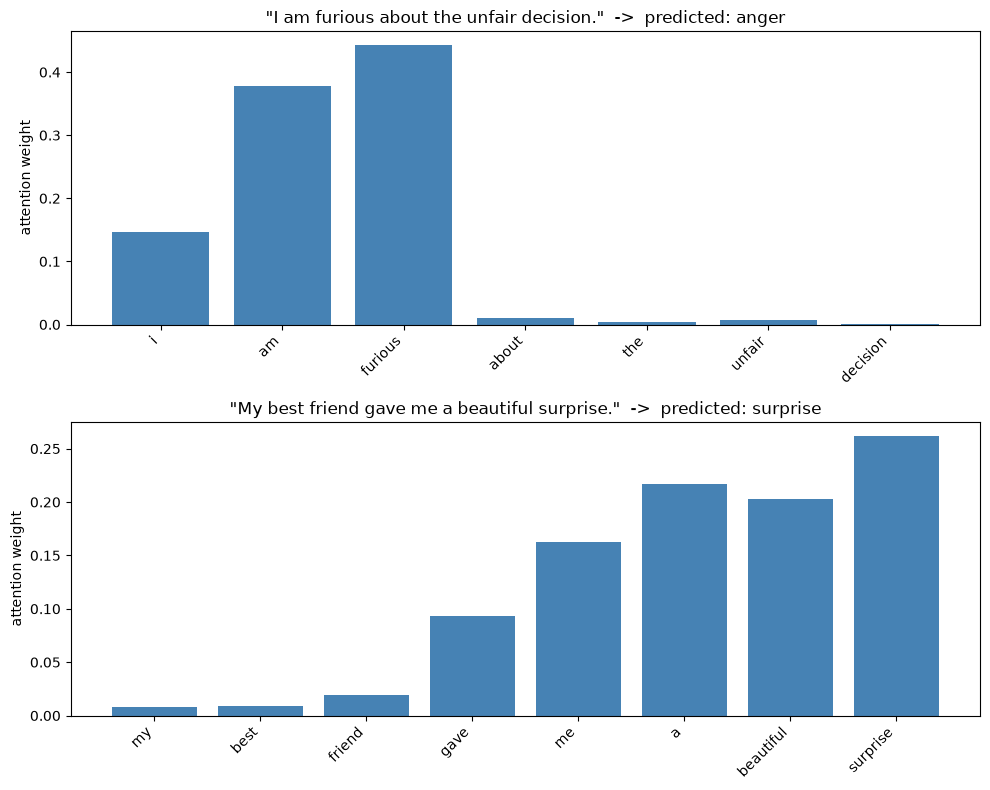

In [32]:
import matplotlib.pyplot as plt

def plot_attention(sentence, ax):
    seq = pad_sequences(tokenizer.texts_to_sequences([sentence]), maxlen=50, padding="post", truncating="post")
    weights = attention_weight_model.predict(seq)[0].flatten()   # (50,)
    pred_class = label_names[np.argmax(BiGRU_Attention.predict(seq), axis=1)[0]]

    tokens = tokenizer.texts_to_sequences([sentence])[0]
    words = [tokenizer.index_word.get(t, "?") for t in tokens][:50]
    word_weights = weights[:len(words)]

    ax.bar(range(len(words)), word_weights, color="steelblue")
    ax.set_xticks(range(len(words)))
    ax.set_xticklabels(words, rotation=45, ha="right")
    ax.set_title(f'"{sentence}"  ->  predicted: {pred_class}')
    ax.set_ylabel("attention weight")

fig, axes = plt.subplots(2, 1, figsize=(10, 8))
plot_attention("I am furious about the unfair decision.", axes[0])
plot_attention("My best friend gave me a beautiful surprise.", axes[1])
plt.tight_layout()
plt.savefig("../artifacts/attention_visualization.png", dpi=120)
plt.show()


### Saving this model

Only doing this if it actually beat the baseline - no point saving a worse model over the one that already works.

In [33]:
import os
attn_model_dir = "../artifacts/models"
os.makedirs(attn_model_dir, exist_ok=True)
BiGRU_Attention.save(os.path.join(attn_model_dir, "BiGRU_Attention_Model.keras"))
print("Saved BiGRU_Attention_Model.keras")


Saved BiGRU_Attention_Model.keras


## Trying GloVe pretrained embeddings

The attention layer barely moved anything - test accuracy stayed about the same and it did not really improve on my own sentences either. I looked at where both models were failing and it kept being the same thing - the "love" examples especially. That made me think the actual issue isn't how the model processes the sequence, it's that the embedding layer has basically no idea what most of these words mean. It's trained from scratch on only ~16k tweets, so words like "grateful" or "furious" probably barely showed up enough times to learn anything useful about them.

So instead of learning embeddings from scratch, I'm loading GloVe vectors here - these are pretrained on billions of words of normal English text, so the model at least starts out already knowing roughly what words mean, instead of learning that from a tiny dataset.

Same architecture as the attention model above, same everything, I'm literally only changing how the Embedding layer gets initialized.

Needed to download glove.6B.zip manually from https://nlp.stanford.edu/projects/glove/ for this (it's about 800mb zipped), I'm using the 300d version since that matches my embedding size.

In [34]:
import os
import numpy as np

GLOVE_PATH = "../artifacts/glove.6B.300d.txt"   # <-- change this if you saved it elsewhere
EMBEDDING_DIM = 300

if not os.path.exists(GLOVE_PATH):
    raise FileNotFoundError(
        f"GloVe file not found at {GLOVE_PATH}. Download glove.6B.zip from "
        "https://nlp.stanford.edu/projects/glove/, unzip it, and set GLOVE_PATH "
        "to the glove.6B.300d.txt file."
    )

print("Loading GloVe vectors (this can take 1-2 minutes)...")
glove_index = {}
with open(GLOVE_PATH, encoding="utf-8") as f:
    for line in f:
        values = line.split()
        word = values[0]
        vector = np.asarray(values[1:], dtype="float32")
        glove_index[word] = vector

print(f"Loaded {len(glove_index)} word vectors from GloVe.")


Loading GloVe vectors (this can take 1-2 minutes)...
Loaded 400000 word vectors from GloVe.


### Building the embedding matrix

For every word in my tokenizer's vocab, grab its vector from GloVe if it exists. If GloVe doesn't have it (probably a typo, or some rare word), just leave it as a small random vector - there's nothing to copy for that one anyway.

In [35]:
embedding_matrix = np.random.normal(scale=0.1, size=(max_words, EMBEDDING_DIM)).astype("float32")

found, missing = 0, 0
for word, idx in tokenizer.word_index.items():
    if idx >= max_words:
        continue
    vector = glove_index.get(word)
    if vector is not None:
        embedding_matrix[idx] = vector
        found += 1
    else:
        missing += 1

print(f"Words matched to GloVe : {found}")
print(f"Words NOT found in GloVe (kept random init) : {missing}")
print(f"Coverage: {found / (found + missing):.1%}")


Words matched to GloVe : 9644
Words NOT found in GloVe (kept random init) : 355
Coverage: 96.4%


### Building the model

Exact same model as the attention one above, just swapping in the GloVe matrix as the starting weights for the embedding layer instead of random init. Keeping trainable=True so it can still adjust a bit during training.

In [36]:
from tensorflow.keras.layers import Embedding, Bidirectional, GRU, Dropout, Dense, Input
from tensorflow.keras.models import Model

glove_input = Input(shape=(50,), name="input_tokens_glove")
g = Embedding(
    input_dim=max_words,
    output_dim=EMBEDDING_DIM,
    weights=[embedding_matrix],
    trainable=True,
    name="glove_embedding"
)(glove_input)

g = Bidirectional(GRU(128, return_sequences=True))(g)
g = Dropout(0.5)(g)
g = Bidirectional(GRU(64, return_sequences=True))(g)
g = Dropout(0.5)(g)

glove_context, glove_attention_weights = BahdanauAttention(units=64)(g)
glove_output = Dense(num_classes, activation="softmax")(glove_context)

BiGRU_Attention_GloVe = Model(inputs=glove_input, outputs=glove_output, name="BiGRU_Attention_GloVe")
BiGRU_Attention_GloVe.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])
BiGRU_Attention_GloVe.summary()


Model: "BiGRU_Attention_GloVe"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_tokens_glove (InputLayer) │ (None, 50)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ glove_embedding (Embedding)     │ (None, 50, 300)        │     3,000,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_4 (Bidirectional) │ (None, 50, 256)        │       330,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_10 (Dropout)            │ (None, 50, 256)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_5 (Bidirectional) │ (None, 50, 128)        │       123,648 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 50, 128)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bahdanau_attention_1            │ [(None, 128), (None,   │         8,320 │
│ (BahdanauAttention)             │ 50, 1)]                │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 6)              │           774 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,462,982 (13.21 MB)

 Trainable params: 3,462,982 (13.21 MB)

 Non-trainable params: 0 (0.00 B)

In [37]:
# Same training config as Experiments above -- only the embedding initialization differs.
BiGRU_Attention_GloVe.fit(
    padded_train_sequence,
    train_labels,
    validation_data=(padded_val_sequence, val_labels),
    epochs=20,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=[early_stopping]
)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 78s 115ms/step - accuracy: 0.8249 - loss: 0.4801 - val_accuracy: 0.9250 - val_loss: 0.2191
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 74s 119ms/step - accuracy: 0.9470 - loss: 0.1427 - val_accuracy: 0.9315 - val_loss: 0.1822
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 72s 114ms/step - accuracy: 0.9635 - loss: 0.0920 - val_accuracy: 0.9330 - val_loss: 0.1989
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 76s 122ms/step - accuracy: 0.9773 - loss: 0.0591 - val_accuracy: 0.9310 - val_loss: 0.2204
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 86s 138ms/step - accuracy: 0.9857 - loss: 0.0377 - val_accuracy: 0.9320 - val_loss: 0.2579


### Checking the test set again, comparing all 3 models so far

In [38]:
from sklearn.metrics import classification_report, confusion_matrix, f1_score

glove_loss, glove_accuracy = BiGRU_Attention_GloVe.evaluate(padded_test_sequence, test_labels)
glove_y_pred = np.argmax(BiGRU_Attention_GloVe.predict(padded_test_sequence), axis=1)
glove_macro_f1 = f1_score(test_labels, glove_y_pred, average="macro")
glove_weighted_f1 = f1_score(test_labels, glove_y_pred, average="weighted")

print(f"{'Model':<28}{'Accuracy':<12}{'Macro F1':<12}{'Weighted F1':<12}")
print("-" * 64)
print(f"{'Baseline BiGRU':<28}{BiGRU_accuracy:<12.4f}{macro_f1:<12.4f}{weighted_f1:<12.4f}")
print(f"{'BiGRU + Attention':<28}{attn_accuracy:<12.4f}{attn_macro_f1:<12.4f}{attn_weighted_f1:<12.4f}")
print(f"{'BiGRU + Attention + GloVe':<28}{glove_accuracy:<12.4f}{glove_macro_f1:<12.4f}{glove_weighted_f1:<12.4f}")

print()
print("=== BiGRU + Attention + GloVe -- classification report ===")
print(classification_report(test_labels, glove_y_pred, target_names=label_names, digits=4))
print("Confusion matrix:")
print(confusion_matrix(test_labels, glove_y_pred))


63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.9280 - loss: 0.1661
63/63 ━━━━━━━━━━━━━━━━━━━━ 3s 40ms/step
Model                       Accuracy    Macro F1    Weighted F1 
----------------------------------------------------------------
Baseline BiGRU              0.9150      0.8697      0.9162      
BiGRU + Attention           0.9160      0.8709      0.9168      
BiGRU + Attention + GloVe   0.9280      0.8831      0.9295      

=== BiGRU + Attention + GloVe -- classification report ===
              precision    recall  f1-score   support

     sadness     0.9928    0.9484    0.9701       581
         joy     0.9685    0.9295    0.9486       695
        love     0.7566    0.8994    0.8218       159
       anger     0.9135    0.9600    0.9362       275
        fear     0.8821    0.9018    0.8918       224
    surprise     0.7042    0.7576    0.7299        66

    accuracy                         0.9280      2000
   macro avg     0.8696    0.8994    0.8831      2000
weighted avg 

### Same OOD sentences, now with all three models

Reusing the exact same 24 sentences from before so this stays a fair comparison.

In [39]:
glove_pred = np.argmax(BiGRU_Attention_GloVe.predict(ood_seq), axis=1)
glove_ood_acc = (glove_pred == ood_true).mean()

print(f"{'Text':<55}{'True':<10}{'Baseline':<12}{'Attention':<12}{'+GloVe':<12}")
print("-" * 101)
for text, true_l, b_l, a_l, g_l in zip(ood_texts, ood_true, baseline_pred, attn_pred, glove_pred):
    def tag(pred_l):
        return f"{label_names[pred_l]} {'OK' if pred_l == true_l else 'X'}"
    print(f"{text[:53]:<55}{label_names[true_l]:<10}{tag(b_l):<12}{tag(a_l):<12}{tag(g_l):<12}")

print()
print(f"Baseline BiGRU accuracy on OOD set              : {baseline_ood_acc:.2%}")
print(f"BiGRU+Attention accuracy on OOD set              : {attn_ood_acc:.2%}")
print(f"BiGRU+Attention+GloVe accuracy on OOD set        : {glove_ood_acc:.2%}")


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Text                                                   True      Baseline    Attention   +GloVe      
-----------------------------------------------------------------------------------------------------
Today has been a wonderful day.                        joy       joy OK      joy OK      joy OK      
I got the job I always wanted!                         joy       fear X      sadness X   love X      
My best friend gave me a beautiful surprise.           surprise  surprise OK surprise OK surprise OK 
I lost someone very close to me.                       sadness   sadness OK  sadness OK  sadness OK  
Nothing seems to be going right today.                 sadness   fear X      surprise X  surprise X  
I feel lonely and hopeless.                            sadness   sadness OK  sadness OK  sadness OK  
How could they treat me like this?                     anger     surprise X  joy X       love X      
I am furious about the unfair decision.     

### Saving this one too, if it's actually the best

Same idea as before - only overwrite the saved model if this one is genuinely better on the real-world sentences, not just the in-domain test set.

In [40]:
glove_model_dir = "../artifacts/models"
os.makedirs(glove_model_dir, exist_ok=True)
BiGRU_Attention_GloVe.save(os.path.join(glove_model_dir, "BiGRU_Attention_GloVe_Model.keras"))
print("Saved BiGRU_Attention_GloVe_Model.keras")


Saved BiGRU_Attention_GloVe_Model.keras


## Save the Model & Tokenizer
Export trained model and tokenizer artifacts for API deplopment.

In [41]:
import os
import pickle

model_dir =  "../artifacts/models"
os.makedirs(model_dir, exist_ok=True) #yeh folder hai jiske andar sari exported file aane wali hai

#Save our BiGRU Model
BiGRU.save(os.path.join(model_dir, 'BiGRU_Model.keras'))

#Save the tokenizer model
with open(os.path.join(model_dir, 'tokenizer.pkl'), 'wb') as file:
  pickle.dump(tokenizer, file)